In [2]:
import pandas as pd
from math import cos, radians, sqrt
from sklearn.neighbors import BallTree
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon, Point
import numpy as np
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.express as px
import warnings
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
import statsmodels.formula.api as smf
from scipy.stats import skew, kurtosis
from scipy.stats import wilcoxon
from scipy.stats import mannwhitneyu
from matplotlib.ticker import PercentFormatter
from statsmodels.stats.anova import anova_lm
from scipy.stats import shapiro
from statsmodels.stats.multitest import multipletests

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
np.set_printoptions(suppress = True)
# np.set_printoptions(precision = 3)

In [4]:
raw = "C:\\Users\\taavi\\Desktop\\BPHIL\\Raw data\\"
clean = "C:\\Users\\taavi\\Desktop\\BPHIL\\Clean data\\"

In [5]:
parcels = pd.read_csv(clean + 'blight.csv')

In [6]:
dev = pd.read_csv(clean + 'clean_development_expenditures.csv')

### Measuring exposure to development expenditure in each year

In [7]:
dev['year'] = pd.to_datetime(dev['date'], format = 'mixed').dt.year

In [8]:
years = range(dev['year'].min(), dev['year'].max() + 1)

In [9]:
parcels = parcels.merge(pd.DataFrame({'date': years}), how = 'cross').sort_values(by = 'date').reset_index(drop = True)
parcels = parcels.rename(columns = {'date': 'year'})

In [ ]:
full = pd.DataFrame()

earthRadius = 6_378_137 # meters

distances = np.arange(50, 800, 50)
distances_radians = distances / earthRadius
weights = [(i + 1) / len(distances) for i, r in enumerate(distances)][::-1]

for year in tqdm(years):
    parcels_sub = parcels.loc[parcels['year'] == year].reset_index(drop = True)
    values_sub = dev.loc[dev['year'] == year].reset_index(drop = True)

    parcels_coords = np.radians(parcels_sub[['lat', 'lng']].to_numpy())
    values_coords = np.radians(values_sub[['lat', 'lng']].to_numpy())

    value_tree = BallTree(values_coords, metric = 'haversine')
    
    # count demos in each distance bin
    for d_m, d_r in zip(distances, distances_radians):
        indices_within_radius = value_tree.query_radius(parcels_coords, r = d_r)
        counts = [len(idxs) for idxs in indices_within_radius]
        parcels_sub[f'dev_count_{d_m}'] = counts

        sums = [values_sub.loc[idxs, 'value'].sum() for idxs in indices_within_radius]
        parcels_sub[f'dev_sum_{d_m}'] = sums
        

    parcels_sub = parcels_sub.fillna(0)

    for i, r in enumerate(distances[::-1]):
        if r != distances[0]:
            parcels_sub[f'dev_count_{r}'] -= parcels_sub[f'dev_count_{distances[::-1][i + 1]}']
            parcels_sub[f'dev_sum_{r}'] -= parcels_sub[f'dev_sum_{distances[::-1][i + 1]}']

    parcels_sub['dev_count_decayed'] = (parcels_sub[[f'dev_count_{r}' for r in distances]] * weights).sum(axis = 1)
    parcels_sub['dev_sum_decayed'] = (parcels_sub[[f'dev_sum_{r}' for r in distances]] * weights).sum(axis = 1)

    parcels_sub['mean_dev_expenditure'] = parcels_sub['dev_sum_decayed'] / parcels_sub['dev_count_decayed']

    top_decile_cutoff_count = parcels_sub['dev_count_decayed'].quantile(0.9)
    parcels_sub['count_exposure'] = np.where(parcels_sub['dev_count_decayed'] > top_decile_cutoff_count, 'High', 'Low')

    top_decile_cutoff_sum = parcels_sub['dev_sum_decayed'].quantile(0.9)
    parcels_sub['sum_exposure'] = np.where(parcels_sub['dev_sum_decayed'] > top_decile_cutoff_sum, 'High', 'Low')

    top_decile_cutoff_mean = parcels_sub['mean_dev_expenditure'].quantile(0.9)
    parcels_sub['mean_dev_expenditure_exposure'] = np.where(parcels_sub['mean_dev_expenditure'] > top_decile_cutoff_mean, 'High', 'Low')

    full = pd.concat([full, parcels_sub], axis = 0)

full = full.reset_index(drop = True)

100%|██████████| 6/6 [56:28<00:00, 564.83s/it]  


In [34]:
full = pd.concat([full.iloc[:, [i for i in range(0, 5)] + [i for i in range(5, 12, 3)] + [i for i in range(7, 14, 3)]], full[['blight', 'pc_blight', 'year', 'dev_count_decayed', 'dev_sum_decayed', 'mean_dev_expenditure', 'count_exposure', 'sum_exposure', 'mean_dev_expenditure_exposure']]], axis = 1)

### Correlations and Regressions

In [37]:
for i in full.iloc[:, -3:].columns:
    full[i] = np.where(full[i] == 'High', 1, 0)

In [46]:
full.iloc[:, -3:].corr()

,count_exposure,sum_exposure,mean_dev_expenditure_exposure
count_exposure,1.00,0.29,0.10
sum_exposure,0.29,1.00,0.75
mean_dev_expenditure_exposure,0.10,0.75,1.00


In [51]:
model = smf.ols(formula = 'mean_dev_expenditure_exposure ~ sum_exposure + count_exposure', data = full).fit()
print(model.summary())

                                  OLS Regression Results                                 
Dep. Variable:     mean_dev_expenditure_exposure   R-squared:                       0.583
Model:                                       OLS   Adj. R-squared:                  0.583
Method:                            Least Squares   F-statistic:                 6.052e+05
Date:                           Fri, 16 Jan 2026   Prob (F-statistic):               0.00
Time:                                   10:27:04   Log-Likelihood:             1.9544e+05
No. Observations:                         864186   AIC:                        -3.909e+05
Df Residuals:                             864183   BIC:                        -3.908e+05
Df Model:                                      2                                         
Covariance Type:                       nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------

In [44]:
full.iloc[:, -6:-3].corr()

,dev_count_decayed,dev_sum_decayed,mean_dev_expenditure
dev_count_decayed,1.00,0.30,0.03
dev_sum_decayed,0.30,1.00,0.68
mean_dev_expenditure,0.03,0.68,1.00


In [53]:
model = smf.ols(formula = 'mean_dev_expenditure ~ dev_sum_decayed + dev_count_decayed', data = full).fit()
print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     mean_dev_expenditure   R-squared:                       0.492
Model:                              OLS   Adj. R-squared:                  0.492
Method:                   Least Squares   F-statistic:                 4.153e+05
Date:                  Fri, 16 Jan 2026   Prob (F-statistic):               0.00
Time:                          10:27:08   Log-Likelihood:            -1.2525e+07
No. Observations:                857876   AIC:                         2.505e+07
Df Residuals:                    857873   BIC:                         2.505e+07
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         

### Distributions of expenditure by blight

In [56]:
full.groupby('blight')['mean_dev_expenditure'].median()

blight
1    18,080.00
2    19,141.00
3    23,081.91
4   113,080.61
5    36,536.58
6    45,497.50
7   400,956.33
Name: mean_dev_expenditure, dtype: float64

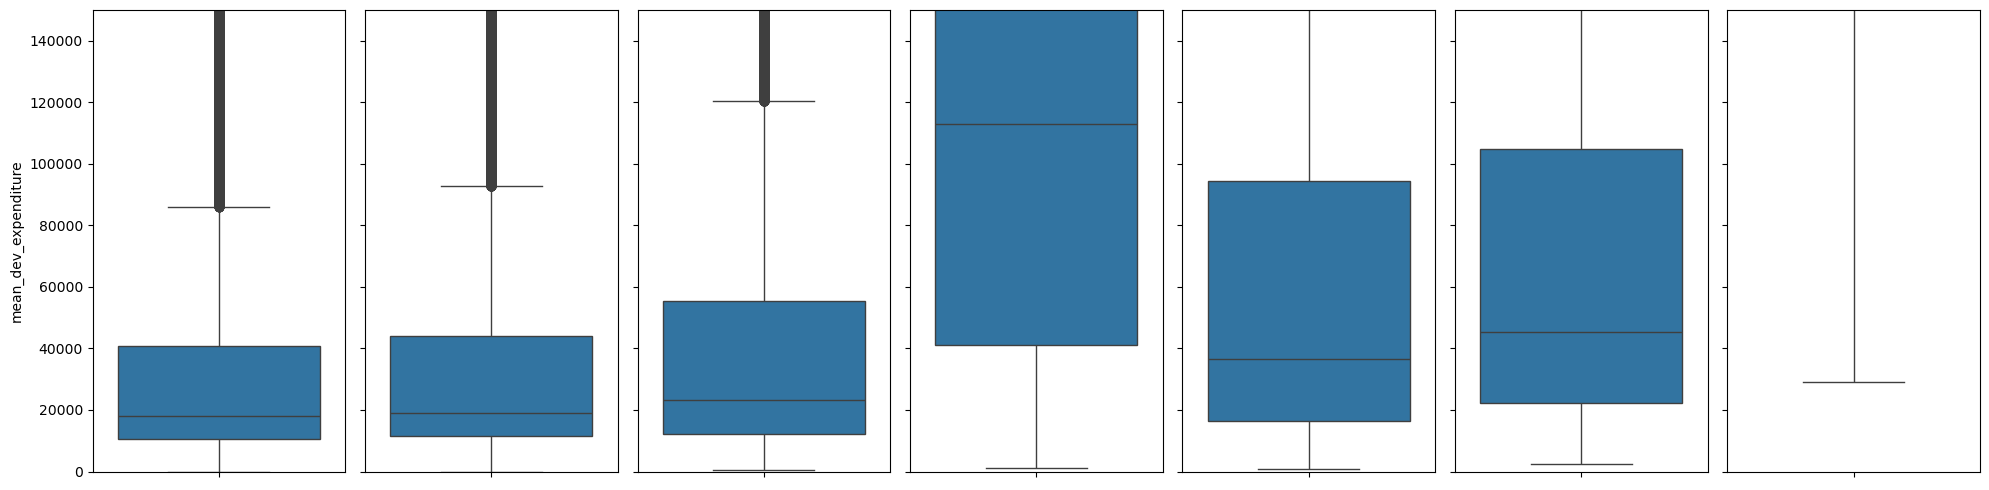

In [64]:
fig, axes = plt.subplots(ncols = 7, nrows = 1, figsize = (20, 5), sharey = True)
for i in range(1, 8):
    sns.boxplot(full.query('blight == @i')['mean_dev_expenditure'], ax = axes[i - 1])
    axes[i - 1].set_ylim(0, 150_000)
plt.tight_layout()
plt.show()

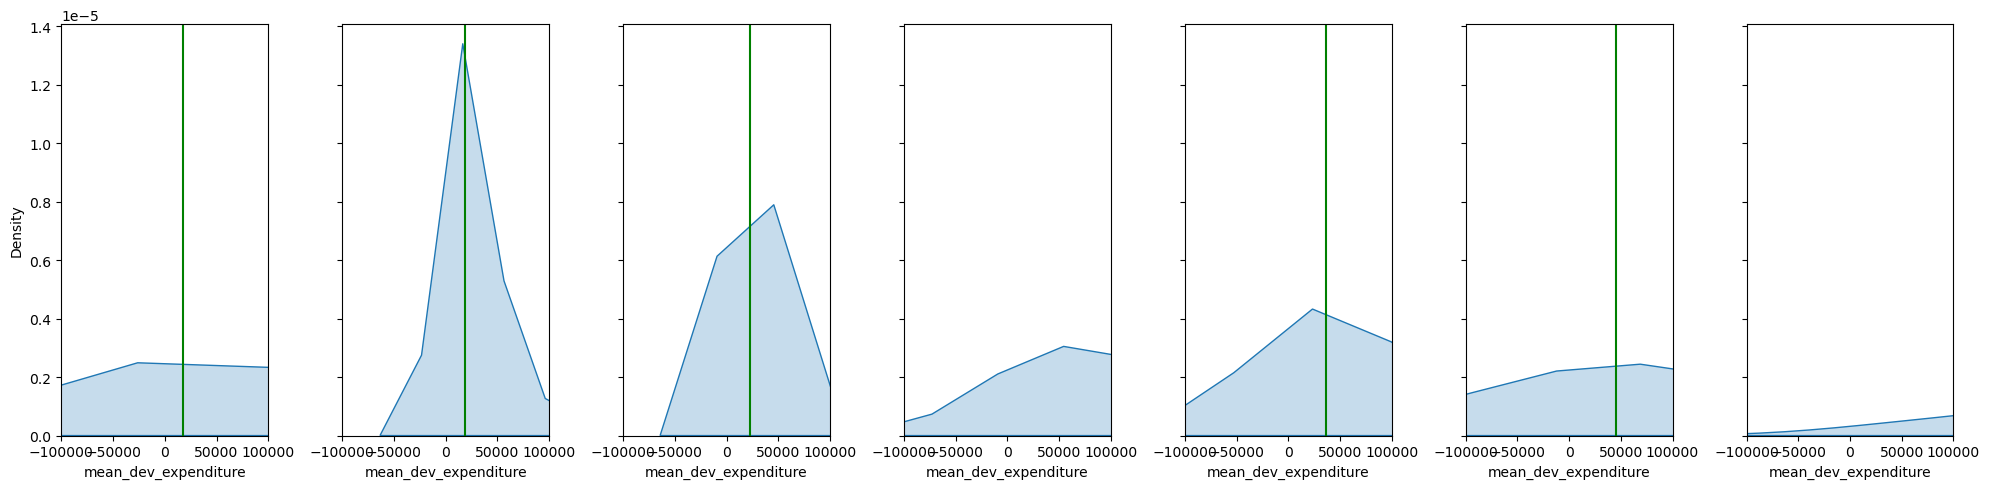

In [80]:
fig, axes = plt.subplots(ncols = 7, nrows = 1, figsize = (20, 5), sharey = True)
for i in range(1, 8):
    toPlot = full.query('blight == @i')['mean_dev_expenditure']
    # mean = toPlot.mean()
    median = toPlot.median()
    sns.kdeplot(toPlot, ax = axes[i - 1], fill = True)
    # axes[i - 1].axvline(x = mean, color = 'blue')
    axes[i - 1].axvline(x = median, color = 'green')
    axes[i - 1].set_xlim(-100_000, 100_000)
plt.tight_layout()
plt.show()

In [81]:
full.groupby('blight')['dev_count_decayed'].median()

blight
1    2.87
2    6.40
3    7.40
4   13.53
5    8.40
6   10.13
7   27.73
Name: dev_count_decayed, dtype: float64

In [82]:
full.groupby('blight')['dev_sum_decayed'].median()


blight
1       53,215.20
2      126,142.00
3      175,892.03
4    1,776,054.20
5      299,858.90
6      490,741.83
7   12,835,624.70
Name: dev_sum_decayed, dtype: float64

#### Breaking down blight 6

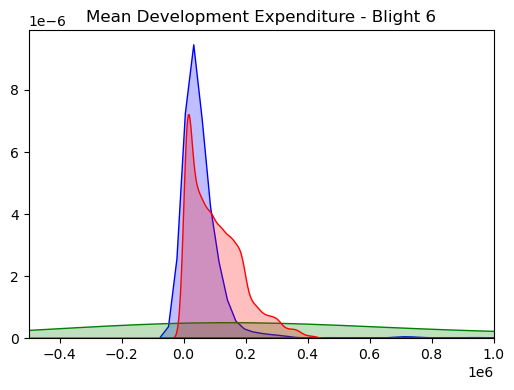

In [95]:
southside = ['South Side Flats', 'South Side Slopes', 'Mount Washington', 'Allentown', 'Arlington Heights', 'Beltzhoover', 'Knoxville', 'Mt. Oliver']
oakland = ['Central Oakland', 'South Oakland']
homewood = ['Homewood West', 'Homewood North', 'Homewood South']

plt.figure(figsize = (6, 4))
toPlot = parcels.query('blight == 6')
toPlot['Area'] = np.where(toPlot['nbrhd'].isin(oakland), 'Oakland', np.where(toPlot['nbrhd'].isin(homewood), 'Homewood', np.where(toPlot['nbrhd'].isin(southside), 'Southside', 'Other')))
sns.kdeplot(toPlot.query('Area == "Southside"')['mean_dev_expenditure'], fill = True, color = 'blue')
sns.kdeplot(toPlot.query('Area == "Oakland"')['mean_dev_expenditure'], fill = True, color = 'green')
sns.kdeplot(toPlot.query('Area == "Homewood"')['mean_dev_expenditure'], fill = True, color = 'red')
plt.title('Mean Development Expenditure - Blight 6')
plt.xlabel('')
plt.ylabel('')
plt.xlim(-500_000, 1_000_000)
plt.show()

In [98]:
toPlot.groupby('Area')['mean_dev_expenditure'].median()

Area
Homewood     87,019.21
Oakland     187,877.14
Southside    37,446.48
Name: mean_dev_expenditure, dtype: float64

### Saving down the data

In [35]:
full.to_csv(clean + 'development_expenditure_exposure.csv', index = False)

In [ ]:
parcels = pd.read_csv(clean + 'development_expenditure_exposure.csv')

### Analyzing expenditure against demolitions

In [83]:
dev = pd.read_csv(clean + 'development_expenditure_exposure.csv')
demos = pd.read_csv(clean + 'blight_and_demos.csv')

In [86]:
parcels = dev.merge(right = demos[['parcelID', 'year', 'demos_count_decayed', 'demos_sum_decayed', 'exposure']], on = ['parcelID', 'year'], how = 'left')

In [102]:
parcels

,parcelID,lat,lng,nbrhd,tract,viols_score,low_score,high_score,viols_sqrt,low_sqrt,high_sqrt,blight,pc_blight,year,dev_count_decayed,dev_sum_decayed,mean_dev_expenditure,count_exposure,sum_exposure,mean_dev_expenditure_exposure,demos_count_decayed,demos_sum_decayed,exposure
0,0087S00206000000,40.42,-79.92,Squirrel Hill South,141400,198.53,19.25,14.49,14.09,4.39,3.81,2,-0.24,2020,5.27,"123,970.07","23,538.62",Low,Low,Low,0.00,0.00,Low
1,0051E00225000000,40.46,-79.95,Bloomfield,80400,400.00,83.38,53.31,20.00,9.13,7.30,3,0.04,2020,10.20,"1,124,586.67","110,253.59",Low,Low,Low,0.47,"11,666.67",Low
2,0051E00226000000,40.46,-79.95,Bloomfield,80400,399.07,83.79,53.54,19.98,9.15,7.32,3,0.04,2020,10.33,"1,197,757.87","115,912.05",Low,Low,Low,0.47,"11,666.67",Low
3,0051E00227000000,40.46,-79.95,Bloomfield,80400,388.40,83.42,53.60,19.71,9.13,7.32,3,0.03,2020,10.33,"1,197,588.47","115,895.66",Low,Low,Low,0.47,"11,666.67",Low
4,0051E00227010100,40.46,-79.95,Bloomfield,80400,390.67,83.19,53.83,19.77,9.12,7.34,3,0.03,2020,10.27,"1,197,522.40","116,641.79",Low,Low,Low,0.47,"11,666.67",Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
864181,0001A00100000000,40.44,-80.01,Central Business District,20100,25.67,62.36,46.21,5.07,7.90,6.80,2,-0.24,2025,3.87,"8,461,802.87","2,188,397.29",Low,High,High,0.00,0.00,Low
864182,8000T04662000000,40.39,-80.00,Brookline,320600,164.67,46.10,21.50,12.83,6.79,4.64,2,-0.19,2025,0.27,593.33,"2,225.00",Low,Low,Low,0.00,0.00,Low
864183,8120X00002000000,40.43,-80.07,Oakwood,562800,197.76,18.97,5.87,14.06,4.36,2.42,1,-0.28,2025,0.00,0.00,NaN,Low,Low,Low,0.00,0.00,Low
864184,8000T04522000000,40.40,-80.00,Brookline,320600,167.20,47.25,22.02,12.93,6.87,4.69,2,-0.19,2025,0.20,686.67,"3,433.33",Low,Low,Low,0.00,0.00,Low


In [103]:
parcels.groupby('blight')['mean_dev_expenditure_exposure'].value_counts(normalize = True)

blight  mean_dev_expenditure_exposure
1       Low                             0.95
        High                            0.05
2       Low                             0.95
        High                            0.05
3       Low                             0.95
        High                            0.05
4       Low                             0.70
        High                            0.30
5       Low                             0.90
        High                            0.10
6       Low                             0.88
        High                            0.12
7       High                            0.74
        Low                             0.26
Name: proportion, dtype: float64

### Examining high exposure without categories 4 and 7

In [116]:
copy = parcels.copy()

copy = copy.query('~blight.isin([4, 7])').reset_index()

full_3 = pd.DataFrame()
for year in years:
    sub = copy.query('year == @year')
    exp_cutoff = sub['dev_count_decayed'].quantile(0.9)
    sub['dev_exposure'] = np.where(sub['dev_count_decayed'] > exp_cutoff, 1, 0)
    demo_cutoff = sub['demos_count_decayed'].quantile(0.9)
    sub['demo_exposure'] = np.where(sub['demos_count_decayed'] > demo_cutoff, 1, 0)
    full_3 = pd.concat([full_3, sub], axis = 0)

copy = full_3.copy().sort_values(by = ['parcelID', 'year'])

In [ ]:
copy['dev_exposure_1'] = copy['dev_exposure'].shift(-1)
copy['dev']

In [114]:
copy.query('demo_exposure == 1 & dev_exposure_1 == 1')

,index,parcelID,lat,lng,nbrhd,tract,viols_score,low_score,high_score,viols_sqrt,low_sqrt,high_sqrt,blight,pc_blight,year,dev_count_decayed,dev_sum_decayed,mean_dev_expenditure,count_exposure,sum_exposure,mean_dev_expenditure_exposure,demos_count_decayed,demos_sum_decayed,exposure,dev_exposure,demo_exposure,dev_exposure_1
1028,1240,0119S00039000000,40.48,-79.95,Upper Lawrenceville,101100,366.37,42.26,23.72,19.14,6.50,4.87,3,-0.09,2020,17.73,"943,701.47","53,216.25",Low,Low,Low,2.93,"55,273.33",High,1,1,1.00
1056,1269,0119S00046000000,40.48,-79.95,Upper Lawrenceville,101100,366.62,43.40,23.93,19.15,6.59,4.89,3,-0.09,2020,17.60,"1,004,164.93","57,054.83",Low,Low,Low,2.87,"54,213.33",High,1,1,1.00
1074,1290,0119S00043000000,40.48,-79.95,Upper Lawrenceville,101100,367.33,43.61,24.16,19.17,6.60,4.92,3,-0.09,2020,17.93,"1,082,064.87","60,338.19",Low,Low,Low,2.87,"54,213.33",High,1,1,1.00
1112,1333,0119S00050000A00,40.48,-79.95,Upper Lawrenceville,101100,359.24,41.95,23.35,18.95,6.48,4.83,3,-0.09,2020,17.67,"999,908.47","56,598.59",Low,Low,Low,2.87,"54,213.33",High,1,1,1.00
1113,1334,0119S00050000B00,40.48,-79.95,Upper Lawrenceville,101100,358.23,41.88,23.39,18.93,6.47,4.84,3,-0.09,2020,17.47,"984,441.80","56,361.17",Low,Low,Low,2.87,"54,213.33",High,1,1,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
778027,860223,0081A00008000A00,40.48,-79.95,Upper Lawrenceville,101100,377.93,40.84,23.20,19.44,6.39,4.82,3,-0.09,2025,6.47,"211,959.00","32,777.16",Low,Low,Low,1.80,"34,200.00",High,0,1,1.00
778526,860961,0081B00153000000,40.48,-79.95,Stanton Heights,101800,256.60,28.71,16.98,16.02,5.36,4.12,2,-0.18,2025,4.40,"60,318.20","13,708.68",Low,Low,Low,1.13,"21,666.67",High,0,1,1.00
779419,862177,0081E00103000000,40.48,-79.95,Upper Lawrenceville,101100,310.73,34.19,20.00,17.63,5.85,4.47,2,-0.14,2025,5.00,"132,104.13","26,420.83",Low,Low,Low,2.07,"39,533.33",High,0,1,1.00
779440,862209,0081E00119000000,40.48,-79.95,Stanton Heights,101800,280.73,30.08,18.01,16.76,5.48,4.24,2,-0.16,2025,4.40,"82,172.87","18,675.65",Low,Low,Low,1.53,"29,266.67",High,0,1,1.00
